In [1]:
 # Environment setup #
################################################################################

import os
import sys
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.pyplot import rc_context
import numpy as np
import pandas as pd
import scanpy as sc
from anndata import AnnData

scripts_path = '/scratch/user/uqqvo1/Medulloblastoma_analysis/scripts/'
sys.path.append(scripts_path)
from utils import helpers as hs
hs.setUp()
import utils.tools.pseudosampling.pseudosampling as pseudo
from visualisation import helpers as vhs

score_dir = 'data/giotto_out/'
out_plots = 'figure_components/giotto_figures/'

In [2]:
 # Making the violin plots #
################################################################################
#  Loading in the data for the SHH subtypes #
df_names = ['SHH_gsea_v2_scores.txt']
cols = ['GOBP_NEURON_DIFFERENTIATION enrich scores',
        'GOBP_NEUROTRANSMITTER_TRANSPORT enrich scores',
        'HALLMARK_E2F_TARGETS enrich scores',
        'SHH.A enrich scores', 'SHH.B enrich scores', 'SHH.C enrich scores']
for df_name in df_names:
    score_df = pd.read_csv(score_dir+df_name, sep='\t')
new_cols = ['NEURON_DIFFERENTIATION','NEUROTRANSMITTER_TRANSPORT','HALLMARK_E2F_TARGETS',
            'SHHA (proliferative)', 'SHHB (stem)', 'SHHC (neuronal)']
score_df.columns = new_cols
score_adata = AnnData(score_df, dtype=score_df.dtypes[0])

# Splitting into samples #
samples = ['A1', 'B1', 'C1', 'D1']
sample_labels = np.array(['  ']*score_adata.shape[0])
for sample in samples:
    sample_indices = np.where([sample in bc for bc in score_df.index])[0]
    sample_labels[sample_indices] = sample

score_adata.obs['sample'] = pd.DataFrame(sample_labels,
                       index=score_adata.obs_names).iloc[:,0].astype('category')

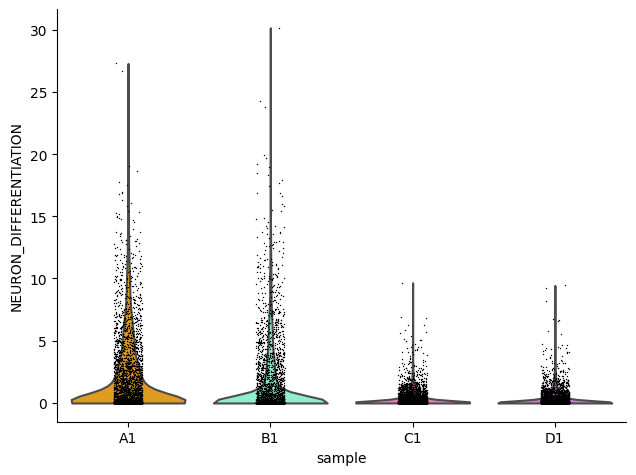

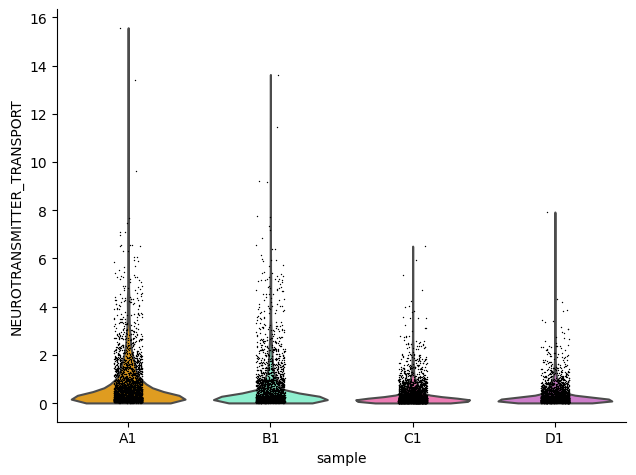

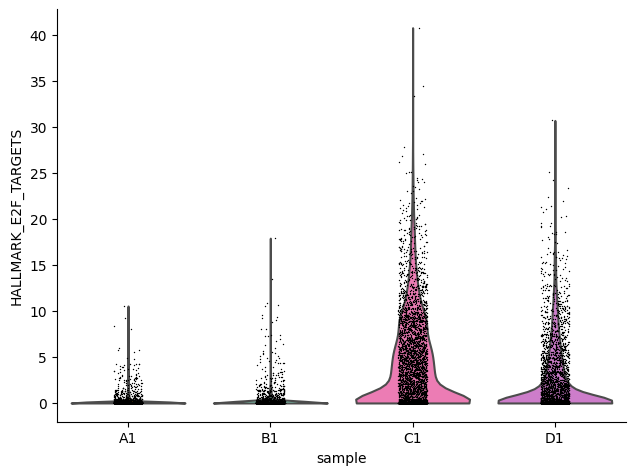

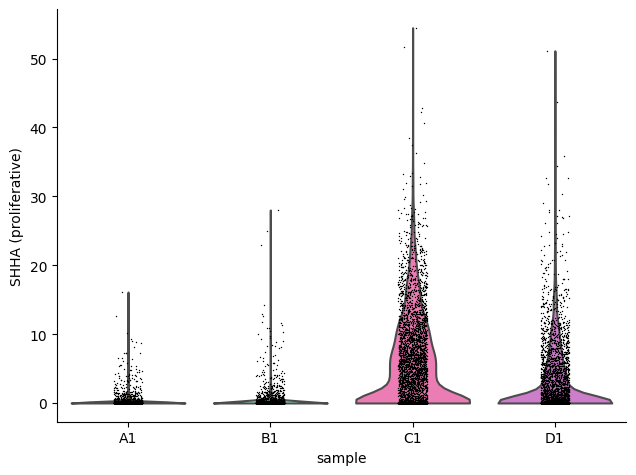

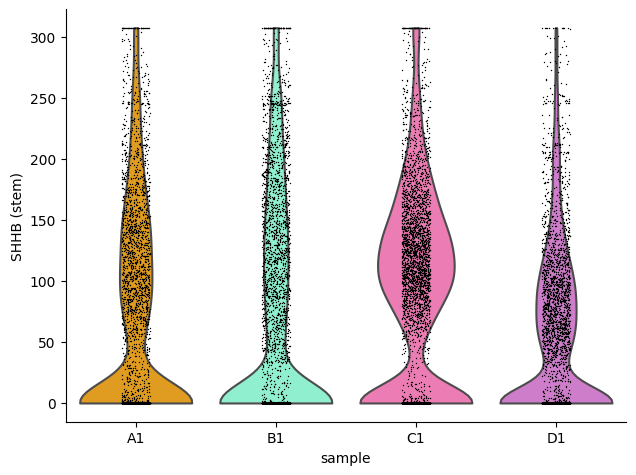

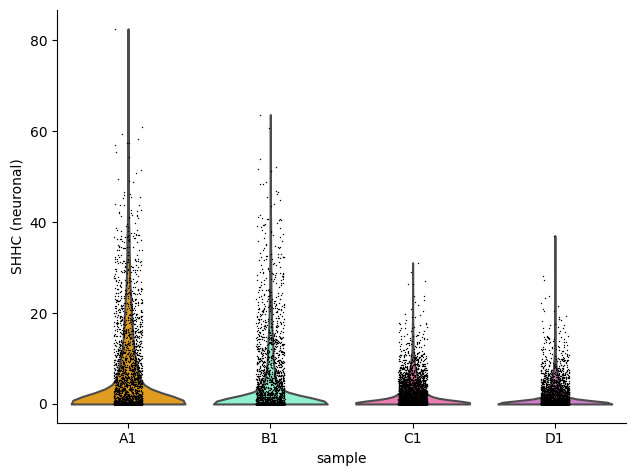

In [3]:
# Copy-pasted from scripts/May_REDO/DE_figures.py
# colors = {'A1': 'firebrick', 'B1': 'royalblue',
#           'C1': 'limegreen', 'D1': 'orchid'}
colors = {'A1': 'orange', 'B1': 'aquamarine',
          'C1': 'hotpink', 'D1': 'orchid'}

score_adata.uns["sample_colors"] = list(colors.values())

for new_col in new_cols:
    fig, axes = plt.subplots()
    matplotlib.rcParams.update()
    with rc_context({'font.size': 8, 'font.weight': 'bold',
                     'figure.figsize': (5,3)}):
        sc.pl.violin(score_adata, new_col, groupby='sample', ax=axes, show=False)
        axes.spines["right"].set_visible(False)
        axes.spines["top"].set_visible(False)
        vhs.dealWithPlot(True, True, True,
                         out_plots, f'{new_col.replace(" ","_")}.pdf', 300)

In [4]:
# Running t-tests to get pair-wise differential abundance #
################################################################################
""" Taking random spots to average the scores between treatment & control to 
    call differential scores for. 
"""

mapping = {'A1': 'treated', 'B1': 'treated',
           'C1': 'untreated', 'D1': 'untreated'}
treat_labels = np.array([mapping[sample] for sample in sample_labels])
metaspot_scores = pseudo.pseudo_sample(score_df.transpose(), treat_labels, 10)
metaspot_scores = metaspot_scores.transpose()

# Pairwise differential expression #
pseudolabels = metaspot_scores.index.values
pseudo_treat_labels = np.array([label.split('_')[0]
                                for label in pseudolabels])

pseudo_data = AnnData(metaspot_scores, dtype=metaspot_scores.dtypes[0])
pseudo_data.obs['treatment'] = pd.Series(pseudo_treat_labels,
                                index=pseudo_data.obs_names).astype('category')

# T-value DE #
sc.tl.rank_genes_groups(pseudo_data, 'treatment', method='t-test')
de_df = pd.DataFrame(pseudo_data.uns['rank_genes_groups']['names'])

# Will need to do it in a pairwise comparison #
from scipy.stats import ttest_rel

stats = np.zeros((metaspot_scores.shape[1], 2))
for score_k, score_type in enumerate(metaspot_scores.columns):
    treated_vals = metaspot_scores.values[pseudo_treat_labels=='treated', score_k]
    untreated_vals = metaspot_scores.values[pseudo_treat_labels=='untreated', score_k]

    t_result = ttest_rel(treated_vals, untreated_vals)
    stats[score_k,:] = [t_result[0], t_result[1]]

stats = pd.DataFrame(stats, index=metaspot_scores.columns, columns=['t_stat', 'pval'])
stats['pval_adj'] = [min(1, val) for val in stats.values[:,-1]*stats.shape[0]]

print(stats)

                               t_stat          pval      pval_adj
NEURON_DIFFERENTIATION      49.042578  3.055451e-12  1.833271e-11
NEUROTRANSMITTER_TRANSPORT  20.150280  8.499325e-09  5.099595e-08
HALLMARK_E2F_TARGETS       -51.136332  2.099907e-12  1.259944e-11
SHHA (proliferative)       -64.403002  2.647676e-13  1.588606e-12
SHHB (stem)                 -3.460148  7.159138e-03  4.295483e-02
SHHC (neuronal)             29.722238  2.698531e-10  1.619118e-09
